# Linear Regression

This section is for pratice and save notes about all learned of this model.

This model is of supervised class. All supervised class refer when in your data you have the value that you try to predict

## Mathematical formula
y_pred = xw - b

*Where*:
- y_pred: y predicted
- x: feature of that affect y
- w: weight or pendient or slope
- b: bias

In [18]:
# import all libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [77]:
# see summaryse of dataset
df = pd.read_csv('./data/houses.csv')
df.head()

,metros_cuadrados,precio
0,50,100000
1,100,180000
2,80,145000
3,120,210000
4,60,115000


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   metros_cuadrados  10 non-null     int64
 1   precio            10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


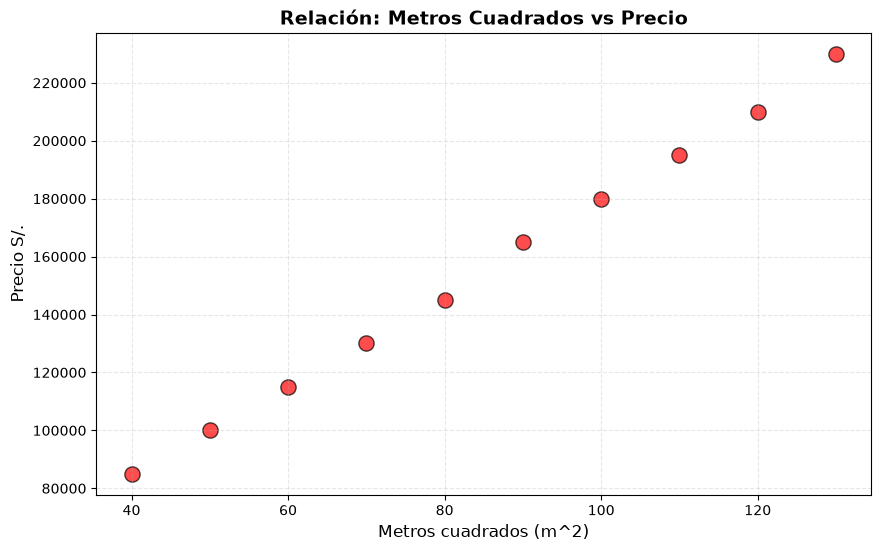

In [79]:
# maket graphic
plt.figure(figsize=(10, 6))

# points
plt.scatter(
    df['metros_cuadrados'],
    df['precio'],
    color='red',
    s=120, # size points
    alpha=0.7, # transparents
    edgecolors='black',
    linewidths=1
)

# labels
plt.title('Relación: Metros Cuadrados vs Precio', fontsize=14, fontweight='bold')
plt.xlabel('Metros cuadrados (m^2)', fontsize=12)
plt.ylabel('Precio S/.', fontsize=12)

# cuadricula
plt.grid(True, alpha=0.3, linestyle='--')
plt.show()

In [98]:
def training_epoch(x, y, w = 0, b = 0):
    n = len(x) # total data
    sum_mae = 0
    sum_mse = 0
    sum_grad_w = 0
    sum_grad_b = 0
    for i in range(n):
        # y predicted or hypothesis
        y_pred = (x[i] * w) + b

        # sum for mae
        error_mae = abs(y[i] - y_pred)
        sum_mae += error_mae

        # sum for mse
        error_mse = (y[i] - y_pred) ** 2
        sum_mse += error_mse

        # sum for w
        sum_grad_w += (y_pred - y[i]) * x[i]

        # sum for b
        sum_grad_b += (y_pred - y[i])

    # loss function | mean squared error
    #mse = sum_mse / (2*n)
    mse = sum_mse / n

    # get mae value
    mae = sum_mae / n

    # get w_grad value
    grad_w = (1/n) * sum_grad_w

    # get b_grad value
    grad_b = (1/n) * sum_grad_b

    return grad_w, grad_b, mse, mae

def get_r2(x, y, w, b):
    y_pred = w * x + b

    ss_res = np.sum((y - y_pred) ** 2)

    ss_tot = np.sum((y - np.mean(y)) ** 2)
    
    # R²
    r2 = 1 - (ss_res / ss_tot)

    return r2

def train(x, y, alpha, epochs):
    w = np.random.rand()
    b = np.random.rand()
    records = {
        'mse': [],
        'mae': [],
        'w': [],
        'b': []
    }
    for _ in range(epochs):
        grad_w, grad_b, mse, mae = training_epoch(x, y, w, b)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        records['mse'].append(mse)
        records['mae'].append(mae)
        records['w'].append(w)
        records['b'].append(b)

    mse_final = records['mse'][-1]

    rmse = np.sqrt(mse_final)

    mae_final = records['mae'][-1]

    w_final = records['w'][-1]
    b_final = records['b'][-1]
    r2 = get_r2(x, y, w_final, b_final)

    return w_final, b_final, r2, mse_final, rmse, mae_final, records

In [82]:
epochs = 1000
alpha = 0.0001 # learning rate

x = df['metros_cuadrados'].values
y = df['precio'].values

w_final, b_final, r2, mse_final, rmse, mae_final, _ = train(x, y, alpha, epochs)
print(f"MSE: {mse_final:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAE: {mae_final:,.0f}")
print(f"R² = {r2:.4f}")

MSE: 19,671,986
RMSE: 4,435
MAE: 5,084
R² = 0.9815


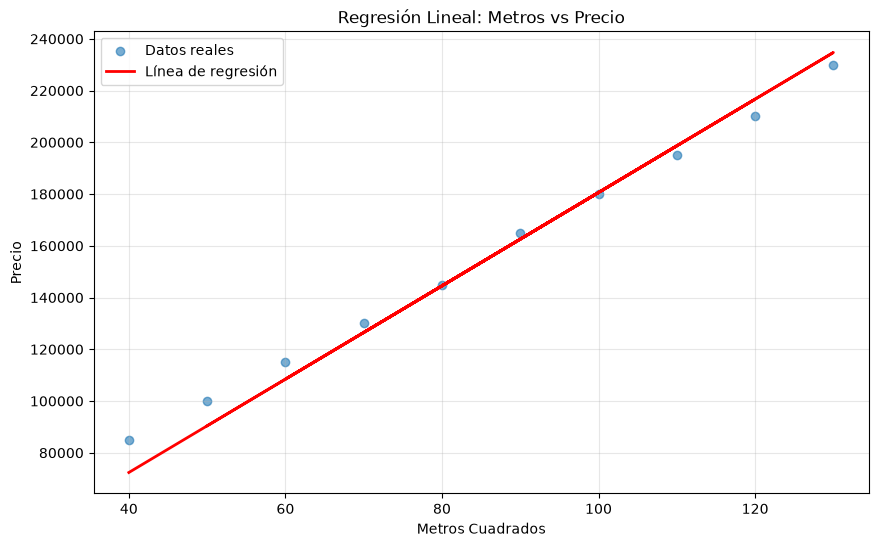

In [83]:
X = df['metros_cuadrados'].values
y = df['precio'].values

# Predicciones
y_pred = w_final * X + b_final

# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Datos reales')
plt.plot(X, y_pred, 'r-', linewidth=2, label='Línea de regresión')
plt.xlabel('Metros Cuadrados')
plt.ylabel('Precio')
plt.title('Regresión Lineal: Metros vs Precio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [84]:
# Icome vs Happiness
df = pd.read_csv('./data/happiness.csv')
df.head()

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  498 non-null    int64  
 1   income      498 non-null    float64
 2   happiness   498 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [86]:
df.describe()

,Unnamed: 0,income,happiness
count,498.000000,498.000000,498.000000
mean,249.500000,4.466902,3.392859
std,143.904482,1.737527,1.432813
min,1.000000,1.506275,0.266044
25%,125.250000,3.006256,2.265864
50%,249.500000,4.423710,3.472536
75%,373.750000,5.991913,4.502621
max,498.000000,7.481521,6.863388


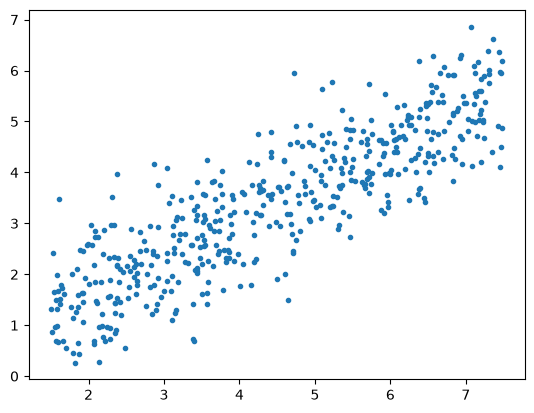

In [87]:
x = df['income'].values
y = df['happiness'].values
plt.plot(x, y, '.')

MSE: 0
RMSE: 1
MAE: 0
R² = 0.7493


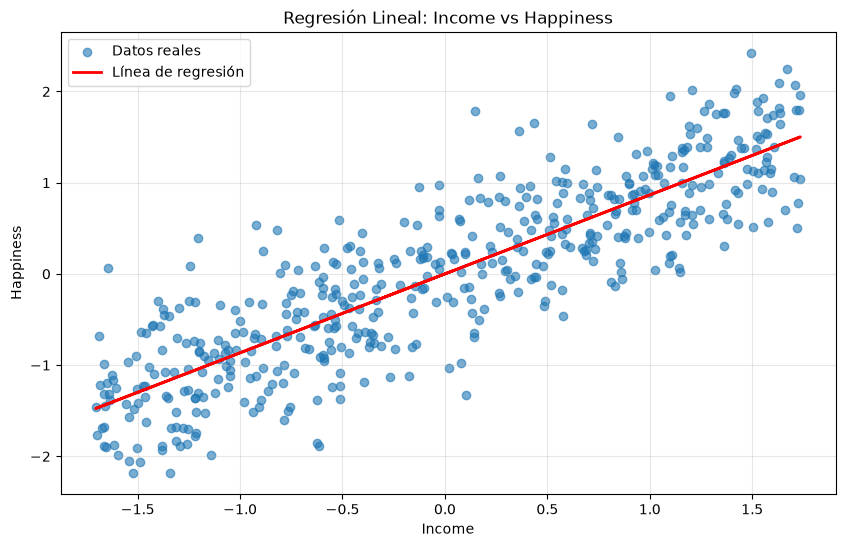

In [123]:
# Data without normalize
alpha = 0.01
epochs = 1000

w_final, b_final, r2, mse_final, rmse, mae_final, records = train(x, y, alpha, epochs)
print(f"MSE: {mse_final:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAE: {mae_final:,.0f}")
print(f"R² = {r2:.4f}")

# Predicciones
y_pred = w_final * x + b_final

# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Datos reales')
plt.plot(x, y_pred, 'r-', linewidth=2, label='Línea de regresión')
plt.xlabel('Income')
plt.ylabel('Happiness')
plt.title('Regresión Lineal: Income vs Happiness')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()